# Network Analyses White Malmö — Cycling Fragmentation & Missing Links

**Study area:** ~1 km² around Triangeln station, Malmö.

## Question

Malmö's protected cycling network is extensive, but a rider only benefits from it where it is
*continuous*. This notebook measures how the protected network **breaks into disconnected
pieces**, and finds the shortest new links that would knit those pieces back together.

## Method

1. Download the OSM bicycle network for the study area.
2. Classify every edge as **protected** (physically separated from motor traffic),
   **painted lane** (in the carriageway), or **mixed traffic**.
3. Take the protected edges as a subgraph and find its **connected components**.
   Each component is a self-contained island of protected infrastructure.
4. Remove all protected edges, then run a multi-source Dijkstra outward from each island
   over the *remaining* (unprotected) streets. Wherever that search reaches another island,
   the path is a **candidate missing link** — and its length is exactly the metres of new
   protected infrastructure needed to close the gap.
5. Rank gaps by **km of stranded network rescued per 100 m of new link**, then compute a
   greedy build order.

Outputs (map, ranked table, GeoPackage) are written to `../OUT/`.

## 0. Dependencies

In [1]:
# Colab / fresh environment. Skip if your env already has these.
# !pip install -q osmnx>=1.9 geopandas networkx matplotlib mapclassify pyogrio

In [2]:
import heapq
import itertools
import math
import socket
from pathlib import Path
from urllib.parse import urlparse

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from matplotlib.lines import Line2D
from shapely.geometry import LineString, Point
from shapely.ops import linemerge, unary_union

print("osmnx     ", ox.__version__)
print("networkx  ", nx.__version__)
print("geopandas ", gpd.__version__)

osmnx      2.1.1
networkx   3.6.1
geopandas  1.1.4


### Version-compatibility shims

OSMnx moved several functions between submodules in the 1.x → 2.x transition
(`graph_to_gdfs` and the undirected conversion in particular). These shims resolve
whichever name the installed version exposes, so the notebook runs on both.

In [3]:
def _resolve(name, *modules):
    for mod in modules:
        if mod is None:
            continue
        fn = getattr(mod, name, None)
        if callable(fn):
            return fn
    return None


def graph_to_gdfs(G, **kwargs):
    fn = _resolve(
        "graph_to_gdfs",
        getattr(ox, "convert", None),      # osmnx >= 2.0
        getattr(ox, "utils_graph", None),  # osmnx 1.x
        ox,                                 # osmnx 1.x top-level alias
    )
    if fn is None:
        raise ImportError("Could not locate osmnx graph_to_gdfs")
    return fn(G, **kwargs)


def to_undirected(G):
    fn = _resolve("to_undirected", getattr(ox, "convert", None), ox)          # osmnx >= 2.0
    if fn is None:
        fn = _resolve("get_undirected", getattr(ox, "utils_graph", None), ox)  # osmnx 1.x
    if fn is None:
        raise ImportError("Could not locate osmnx undirected conversion")
    return fn(G)


def graph_from_polygon(polygon, **kwargs):
    fn = _resolve("graph_from_polygon", getattr(ox, "graph", None), ox)
    if fn is None:
        raise ImportError("Could not locate osmnx graph_from_polygon")
    return fn(polygon, **kwargs)


def project_graph(G, **kwargs):
    fn = _resolve("project_graph", getattr(ox, "projection", None), ox)
    if fn is None:
        raise ImportError("Could not locate osmnx project_graph")
    return fn(G, **kwargs)


# Report what each shim actually bound to - the fastest way to diagnose a
# version problem is to see which module answered.
def _which(name, *modules):
    for mod in modules:
        if mod is not None and callable(getattr(mod, name, None)):
            return f"{getattr(mod, '__name__', mod)}.{name}"
    return "UNRESOLVED"

print("graph_to_gdfs     ->", _which("graph_to_gdfs", getattr(ox, "convert", None),
                                    getattr(ox, "utils_graph", None), ox))
print("to_undirected     ->", _which("to_undirected", getattr(ox, "convert", None), ox),
      "/", _which("get_undirected", getattr(ox, "utils_graph", None), ox))
print("graph_from_polygon->", _which("graph_from_polygon", getattr(ox, "graph", None), ox))
print("project_graph     ->", _which("project_graph", getattr(ox, "projection", None), ox))

graph_to_gdfs     -> osmnx.convert.graph_to_gdfs
to_undirected     -> osmnx.convert.to_undirected / UNRESOLVED
graph_from_polygon-> osmnx.graph.graph_from_polygon
project_graph     -> osmnx.projection.project_graph


## 1. Configuration

In [4]:
# --- Study area -------------------------------------------------------------
# The AOI is centred on Triangeln itself, geocoded from OSM rather than typed in
# by hand, so the square is centred on the place and not on a guessed coordinate.
# OSM carries Triangeln as the pedestrianised square (highway=pedestrian, ~2 880 m2).
TRIANGELN_QUERY = "Triangeln, Malmö, Sweden"

# Used only if Nominatim is unreachable; matches the geocoded centroid.
CENTER_FALLBACK = (55.59689, 13.00132)

AOI_SIDE_M = 1000.0          # square side -> 1000 m x 1000 m = 1.00 km^2
CRS_METRIC = "EPSG:3006"     # SWEREF99 TM - the national projected CRS for Sweden
CRS_WGS84 = "EPSG:4326"

# --- Analysis parameters ----------------------------------------------------
# Do combined foot/cycle paths (gang- och cykelvag: highway=path|footway
# + bicycle=designated|yes) count as protected? They are separated from motor
# traffic, which is the criterion that matters for fragmentation, so: yes.
# Flip to False to restrict "protected" to dedicated cycleways only.
INCLUDE_SHARED_PATHS = True

# Longest gap still treated as a candidate missing link (metres of new
# infrastructure). 300 m is a short-block scale intervention.
MAX_GAP_M = 300.0

# Components shorter than this are reported but flagged as marginal.
MIN_MEANINGFUL_COMP_M = 50.0

TOP_N = 20                   # links drawn on the map and rows in the ranking chart

# --- Paths ------------------------------------------------------------------
OUT_DIR = Path("../OUT")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- OSMnx settings ---------------------------------------------------------
ox.settings.use_cache = True
ox.settings.log_console = False

# --- Overpass endpoint ------------------------------------------------------
# The default host (overpass-api.de) is frequently overloaded or rate-limited,
# and when it is unreachable the download in section 3 dies with a
# ConnectionError. Section 3 tries these in order and keeps the first that
# actually returns data - a TCP probe is not enough, because this host will
# accept a connection and then refuse the query. OSMnx appends "/interpreter"
# itself, so these are base URLs.
#
# Every entry must be a GLOBAL mirror. overpass.osm.ch was in this list and is
# a Switzerland-only instance: it answers HTTP 200 with zero elements for any
# Malmo query, which OSMnx reports as InsufficientResponseError. Sitting last,
# it became the error the fallback loop re-raised, hiding the real (transient)
# failures on the two hosts before it.
# kumi.systems and private.coffee both resolve to 193.219.97.30 - they are one
# machine behind two names, so listing both buys no redundancy.
OVERPASS_ENDPOINTS = [
    "https://overpass-api.de/api",
    "https://overpass.kumi.systems/api",
]



# Retain the tags the classifier needs; OSMnx drops unlisted tags on download.
_extra_tags = [
    "cycleway", "cycleway:left", "cycleway:right", "cycleway:both",
    "bicycle", "segregated", "foot", "sidewalk", "surface", "lit",
    "maxspeed", "width", "oneway:bicycle",
]
ox.settings.useful_tags_way = list(
    dict.fromkeys(list(ox.settings.useful_tags_way) + _extra_tags)
)

print(f"AOI: {AOI_SIDE_M:.0f} m square centred on {TRIANGELN_QUERY!r}")
print(f"protected includes shared foot/cycle paths: {INCLUDE_SHARED_PATHS}")
print(f"max gap: {MAX_GAP_M:.0f} m")

AOI: 1000 m square centred on 'Triangeln, Malmö, Sweden'
protected includes shared foot/cycle paths: True
max gap: 300 m


### Design tokens — White Arkitekter palette

The palette comes from `IN/Color Pallette White Arkitekter.png`. Brand hexes are used
exactly for the surface (White), the ink (Black, Grey), the hairline grid (Misty green),
the no-provision ground (Denim) and the proposed links (Black).

**One deliberate departure, and why.** Brand Teal `#389BAA` carries OKLab chroma 0.092 —
below the chroma floor a 2 px map line needs. Checked against the brand's own neighbours it
is not separable at map scale: `#389BAA` against brand Slate measures ΔE 6.6 in *normal*
vision (floor is 15), and brand Purple against brand Teal measures ΔE 1.9 under protanopia
(floor is 8) — a red-blind reader would see one colour. The palette is built for large
print and web fills, where those pairs are fine; thin lines on white are a different job.

So the three teal marks hold the **brand Teal hue** (9° spread from `#389BAA`) at the
chroma and lightness a line needs. They read as the brand teal, and they survive the
colour-vision checks. Brand Teal itself appears exactly in the ranking chart, where bars
are area fills and the pastel holds up fine.

In [5]:
# ---------------------------------------------------------------------------
# White Arkitekter digital palette (IN/Color Pallette White Arkitekter.png)
# ---------------------------------------------------------------------------
W_MINT        = "#89D0C8"
W_TEAL        = "#389BAA"
W_WHITE       = "#ffffff"
W_BLACK       = "#000000"
W_GREY        = "#777777"
W_DENIM       = "#A1B2BF"
W_DARK_DENIM  = "#6A88A0"
W_PINK        = "#F49AC1"
W_PURPLE      = "#B586A5"
W_MISTY_GREEN = "#C5D5CB"
W_FORREST     = "#6C8C78"
W_SAND        = "#B0A89B"
W_SLATE       = "#7A9193"

# --- chrome: brand-exact -----------------------------------------------------
SURFACE   = W_WHITE
INK       = W_BLACK          # titles, gap labels
INK_2     = W_GREY           # subtitles, legend text
INK_MUTED = "#9e9e9e"        # axis ticks - brand Grey, lightened
GRID      = W_MISTY_GREEN    # hairline grid

# --- map marks ---------------------------------------------------------------
# One ordinal teal ramp carries "how much protected continuity a rider can
# actually use": painted lane (least) -> protected but stranded -> protected and
# joined to the backbone (most). Brand Denim is the no-provision ground, and
# brand Black marks the proposed intervention.
#
# The three teal steps hold the brand Teal hue (9 deg spread from #389BAA) but
# are deepened: the pastel #389BAA has OKLab chroma 0.092, below the chroma
# floor a thin 2 px line needs, so at map scale it cannot hold its identity
# against a neutral of similar lightness. See the validation note below.
C_NONE      = W_DENIM     # no cycling provision          2.18:1
C_LANE      = "#009ab0"   # painted lane in carriageway   3.36:1
C_FRAGMENT  = "#006e81"   # protected, stranded           5.92:1
C_MAIN      = "#003948"   # protected, backbone          12.51:1
C_GAP       = W_BLACK     # proposed missing link        21.00:1

# Triangeln itself is an annotation, not a data class. A sixth hue alongside the
# five above breaks the colour-vision gates in every brand colour tried (best
# case brand Sand, normal-vision dE 5.1 against a floor of 15), so it is
# deliberately NOT given a competing line colour: it is a warm AREA wash under
# the network, named by a direct label. Identity comes from the label, not hue.
C_PLACE     = W_SAND      # Triangeln, as a ground wash

# --- sequential ramp for the ranking chart (brand Teal anchors step 2) -------
SEQ_TEAL = ["#2bb8cc", W_TEAL, "#007385", "#004f5f", "#003340"]

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "text.color": INK,
    "axes.labelcolor": INK_2,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "axes.edgecolor": GRID,
    "axes.linewidth": 0.8,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
})

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

> **Colour validation.** The three-step teal ramp passes as an ordinal ramp: monotone
> lightness, adjacent ΔL ≥ 0.06, 9° hue spread, light end 3.36:1 on white. The three mark
> *families* — Denim ground, teal asset, Black intervention — pass all-pairs colour-vision
> separation at ΔE 23.8 (worst simulated) and 26.7 (normal vision), against floors of 8 and
> 15. Denim at 2.18:1 sits below the 3:1 contrast floor by design, as recessive context;
> the legend and the component tables above are its relief. Contrast ladder on white:
> Denim 2.18 → lane 3.36 → stranded 5.92 → backbone 12.51 → link 21.00.

## 2. Study area

The 1 km² square is centred on **Triangeln itself**, geocoded from OSM rather than typed in
by hand — OSM carries it as the pedestrianised square (`highway=pedestrian`, ~2 880 m²,
92 × 52 m). The cell prints the offset between the shape and the AOI centre as a check, and
the shape is drawn on the map so the study area is visibly anchored to the place it names.


In [6]:
# --- 1. the shape of Triangeln, straight from OSM ---------------------------
try:
    triangeln = ox.geocoder.geocode_to_gdf(TRIANGELN_QUERY).to_crs(CRS_METRIC)
    print(f"geocoded {TRIANGELN_QUERY!r}: {triangeln.geometry.iloc[0].geom_type}, "
          f"{triangeln.geometry.iloc[0].area:,.0f} m2")
except Exception as exc:
    print(f"geocoding failed ({type(exc).__name__}: {exc}); using CENTER_FALLBACK")
    triangeln = gpd.GeoDataFrame(
        {"name": ["Triangeln"]},
        geometry=gpd.points_from_xy([CENTER_FALLBACK[1]], [CENTER_FALLBACK[0]]),
        crs=CRS_WGS84,
    ).to_crs(CRS_METRIC)

TRIANGELN_M = triangeln.geometry.iloc[0]

# --- 2. centre the square on it ---------------------------------------------
# Centre on the representative point rather than the centroid: for a concave or
# multipart shape the centroid can fall outside the geometry.
_centre = TRIANGELN_M.representative_point()

# cap_style=3 buffers a point into a square: side = 2 * distance
AOI_M = _centre.buffer(AOI_SIDE_M / 2.0, cap_style=3)
AOI_WGS84 = gpd.GeoSeries([AOI_M], crs=CRS_METRIC).to_crs(CRS_WGS84).iloc[0]

aoi_gdf = gpd.GeoDataFrame({"name": ["Triangeln AOI"]}, geometry=[AOI_M], crs=CRS_METRIC)

_c_ll = gpd.GeoSeries([_centre], crs=CRS_METRIC).to_crs(CRS_WGS84).iloc[0]
w, s, e, n = AOI_WGS84.bounds
print(f"\ncentred on    lat {_c_ll.y:.5f}  lon {_c_ll.x:.5f}")
print(f"area           {AOI_M.area / 1e6:.4f} km^2")
print(f"bbox (WGS84)   W {w:.5f}  S {s:.5f}  E {e:.5f}  N {n:.5f}")
print(f"bbox (SWEREF)  {tuple(round(v, 1) for v in AOI_M.bounds)}")

# Triangeln should now sit dead centre - confirm it numerically.
_off_x = _centre.x - AOI_M.centroid.x
_off_y = _centre.y - AOI_M.centroid.y
print(f"offset from AOI centre: {_off_x:.1f} m E, {_off_y:.1f} m N")

geocoded 'Triangeln, Malmö, Sweden': Polygon, 2,880 m2

centred on    lat 55.59685  lon 13.00132
area           1.0000 km^2
bbox (WGS84)   W 12.99316  S 55.59223  E 13.00948  N 55.60147
bbox (SWEREF)  (373561.6, 6162524.0, 374561.6, 6163524.0)
offset from AOI centre: 0.0 m E, -0.0 m N


## 3. Download and prepare the bicycle network

In [7]:
# truncate_by_edge=True keeps edges that cross the AOI boundary, so infrastructure
# is not artificially severed at the window edge.
# retain_all=True keeps every piece OSM returns inside the window - dropping
# disconnected pieces would bias a fragmentation analysis.
# --- pin a live server, not just the first A record -------------------------
# OSMnx deliberately pins ONE server IP per request: _config_dns() resolves the
# Overpass hostname once and mutates socket.getaddrinfo so the rate-limit check
# and the query itself reach the same machine, which is what keeps its slot
# management honest. It picks that IP with socket.gethostbyname, which returns
# whichever A record the resolver hands back first, alive or not.
#
# overpass-api.de publishes two: 65.109.112.52 and 162.55.144.139.
# gethostbyname here deterministically returns .52, so if .52 is refusing
# connections every attempt fails identically and the second server is never
# tried - a retry loop cannot help, because it re-resolves to the same dead IP.
#
# So: keep OSMnx's one-server guarantee, but choose the server ourselves.
# We TCP-probe each A record and pin the first that accepts on :443, then hand
# that address to OSMnx by patching the single function _config_dns() calls.
# Patching gethostbyname (not getaddrinfo) is deliberate - OSMnx wraps its own
# captured _original_getaddrinfo, so a getaddrinfo patch would be bypassed.
_ORIGINAL_GETHOSTBYNAME = globals().get("_ORIGINAL_GETHOSTBYNAME", socket.gethostbyname)
_PINNED_IPS = {}


def _a_records(hostname):
    # OSMnx mutates socket.getaddrinfo mid-request but keeps the original.
    getaddrinfo = getattr(
        getattr(ox, "_http", None), "_original_getaddrinfo", socket.getaddrinfo
    )
    infos = getaddrinfo(hostname, 443, socket.AF_INET, socket.SOCK_STREAM)
    return sorted({info[4][0] for info in infos})


def _accepts_connections(ip, timeout=4.0):
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.settimeout(timeout)
    try:
        return sock.connect_ex((ip, 443)) == 0
    finally:
        sock.close()


def pin_live_ip(endpoint):
    """Pin `endpoint`'s hostname to an A record that is accepting connections."""
    hostname = urlparse(endpoint).hostname
    try:
        ips = _a_records(hostname)
    except OSError as exc:
        print(f"  {hostname}: DNS lookup failed ({type(exc).__name__})")
        return False

    for ip in ips:
        if _accepts_connections(ip):
            _PINNED_IPS[hostname] = ip
            default = _ORIGINAL_GETHOSTBYNAME(hostname)
            note = f" (default {default} is not answering)" if ip != default else ""
            print(f"  {hostname}: pinned {ip} of {len(ips)}{note}")
            return True

    print(f"  {hostname}: no live A record - all refused :443 ({', '.join(ips)})")
    return False


def _gethostbyname(hostname):
    return _PINNED_IPS.get(hostname) or _ORIGINAL_GETHOSTBYNAME(hostname)


socket.gethostbyname = _gethostbyname


def download_bike_network(polygon, endpoints):
    # Probe by doing the real thing: an endpoint will accept a TCP connection
    # and then refuse the query, so only a completed download proves it works.
    # The IP pin above only rules out hosts that are refusing outright.
    last = None
    for url in endpoints:
        if not pin_live_ip(url):
            continue
        ox.settings.overpass_url = url
        try:
            G = graph_from_polygon(
                polygon,
                network_type="bike",
                simplify=True,
                retain_all=True,
                truncate_by_edge=True,
            )
            print(f"downloaded from {url}")
            return G
        except Exception as exc:
            print(f"  {url} failed: {type(exc).__name__}")
            last = exc
    raise RuntimeError(
        f"every Overpass endpoint failed; last error: {last!r}"
    ) from last


G_raw = download_bike_network(AOI_WGS84, OVERPASS_ENDPOINTS)

# Order matters: project FIRST, collapse to undirected SECOND.
# ox.project_graph round-trips through graph_from_gdfs, which always rebuilds a
# MultiDiGraph - so projecting an undirected graph silently re-directs it, and
# nx.connected_components then raises NetworkXNotImplemented.
G = project_graph(G_raw, to_crs=CRS_METRIC)

# Fragmentation is a bidirectional, planning-level question: collapse the
# reciprocal directed pair into a single undirected edge per street segment.
G = to_undirected(G)

if G.is_directed():
    raise RuntimeError(
        "Graph is still directed after to_undirected(); the component analysis "
        "below needs an undirected MultiGraph. Check the osmnx shim resolution."
    )

print(f"nodes {G.number_of_nodes():,}   edges {G.number_of_edges():,}")
print(f"graph CRS: {G.graph['crs']}")
print(f"type: {type(G).__name__}  directed: {G.is_directed()}")

  overpass-api.de: pinned 65.109.112.52 of 2 (default 162.55.144.139 is not answering)


downloaded from https://overpass-api.de/api
nodes 357   edges 529
graph CRS: EPSG:3006
type: MultiGraph  directed: False


In [8]:
edges = graph_to_gdfs(G, nodes=False)
nodes = graph_to_gdfs(G, edges=False)

print(f"edges gdf: {edges.shape}")
print("tag columns present:",
      [c for c in edges.columns if c in _extra_tags or c in ("highway", "name")])
edges.head(3)

edges gdf: (529, 27)
tag columns present: ['highway', 'name', 'surface', 'lit', 'maxspeed', 'cycleway:right', 'sidewalk', 'cycleway:both', 'bicycle', 'segregated', 'foot', 'width', 'cycleway', 'cycleway:left', 'oneway:bicycle']


osmid     highway       name  surface  lit  oneway reversed     length                                           geometry  \
u        v           key                                                                                                                                  
26804452 92777354    0     10608593  pedestrian  Triangeln     sett  yes   False    False  84.569482  LINESTRING (374050.555 6163053.022, 374062.921...   
         10992116342 0    139640936    tertiary  Triangeln  asphalt  yes    True    False  14.807431  LINESTRING (374108.673 6163000.948, 374096.491...   
         2557926059  0    249121405     service        NaN  asphalt  NaN    True    False   9.117468  LINESTRING (374108.673 6163000.948, 374106.744...   

                              from           to lanes maxspeed cycleway:right sidewalk cycleway:both bicycle segregated foot width cycleway cycleway:left  \
u        v           key                                                                                                                                    
26804452 92777354    0    92777354     26804452   NaN      NaN            NaN      NaN           NaN     NaN        NaN  NaN   NaN      NaN           NaN   
         10992116342 0    26804452  10992116342     2       30             no    right           NaN     NaN        NaN  NaN   NaN      NaN           NaN   
         2557926059  0    26804452   2557926059   NaN       30            NaN      NaN           NaN     NaN        NaN  NaN   NaN      NaN           NaN   

                         bridge tunnel service oneway:bicycle access  
u        v           key                                              
26804452 92777354    0      NaN    NaN     NaN            NaN    NaN  
         10992116342 0      NaN    NaN     NaN            NaN    NaN  
         2557926059  0      NaN    NaN     NaN            NaN    NaN

## 4. Classify cycling infrastructure

OSM records cycling provision in two different idioms: as a **way of its own**
(`highway=cycleway`, or a combined path with `bicycle=designated`) or as a **tag on a road**
(`cycleway=track` / `cycleway=lane` and their `:left` / `:right` / `:both` variants). The
classifier reads both, and collapses to three classes on the one axis that matters for
fragmentation — whether a rider is separated from motor traffic.

Note that OSMnx returns a *list* rather than a scalar wherever it merged parallel OSM ways
into one simplified edge, so every tag lookup is normalised to a set of values first.

In [9]:
PROTECTED, LANE, MIXED = "protected", "lane", "mixed"

CYCLEWAY_KEYS = ["cycleway", "cycleway:left", "cycleway:right", "cycleway:both"]
PROTECTED_CW_VALUES = {"track", "opposite_track", "sidepath"}
LANE_CW_VALUES = {
    "lane", "opposite_lane", "buffered_lane", "shared_lane",
    "share_busway", "opposite_share_busway", "crossing",
}
PATHY_HIGHWAYS = {"path", "footway", "pedestrian", "track", "bridleway"}
BIKE_ALLOWED = {"designated", "yes"}


def tagset(value):
    # Normalise an OSM tag value to a lowercase set; handles None, NaN and lists.
    if value is None:
        return set()
    if isinstance(value, float) and math.isnan(value):
        return set()
    if isinstance(value, (list, tuple, set)):
        out = set()
        for item in value:
            out |= tagset(item)
        return out
    text = str(value).strip().lower()
    return {text} if text and text != "nan" else set()


def classify_edge(row):
    highway = tagset(row.get("highway"))
    bicycle = tagset(row.get("bicycle"))
    cycleway = set()
    for key in CYCLEWAY_KEYS:
        cycleway |= tagset(row.get(key))

    # --- protected: separated from motor traffic ---
    if "cycleway" in highway:
        return PROTECTED
    if cycleway & PROTECTED_CW_VALUES:
        return PROTECTED
    if INCLUDE_SHARED_PATHS and (highway & PATHY_HIGHWAYS) and (bicycle & BIKE_ALLOWED):
        return PROTECTED

    # --- painted lane: marked, but inside the carriageway ---
    if cycleway & LANE_CW_VALUES:
        return LANE

    return MIXED


edges["infra"] = edges.apply(classify_edge, axis=1)

# Push the class back onto the graph, keyed by the (u, v, key) index so the
# graph and the GeoDataFrame stay in exact correspondence.
infra_by_edge = dict(zip(edges.index, edges["infra"]))
nx.set_edge_attributes(G, infra_by_edge, "infra")

summary = (
    edges.groupby("infra")["length"]
    .agg(segments="count", km=lambda s: s.sum() / 1000.0)
    .reindex([PROTECTED, LANE, MIXED])
    .fillna(0)
)
summary["share_of_km"] = 100 * summary["km"] / summary["km"].sum()
summary.round(2)

,segments,km,share_of_km
infra,,,
protected,141,8.37,26.24
lane,5,0.71,2.24
mixed,383,22.82,71.52


## 5. The protected subnetwork and its components

In [10]:
protected_keys = [key for key, cls in infra_by_edge.items() if cls == PROTECTED]

if not protected_keys:
    raise RuntimeError(
        "No protected edges found. Check that ox.settings.useful_tags_way was set "
        "before download, or widen the AOI."
    )

# Section 3 collapses G to an undirected MultiGraph, and everything below
# depends on that: nx.connected_components refuses a directed graph outright,
# and the gap search in section 6 would silently follow out-edges only. Check
# the invariant here rather than trusting a cell five sections up - a kernel
# still holding a pre-conversion G otherwise fails deep inside NetworkX with a
# bare "not implemented for directed type".
#
# Do not convert here as a fix: infra_by_edge is keyed on this G's (u, v, k)
# edge keys, and to_undirected() renumbers parallel-edge keys, so the keys
# would no longer address the same edges.
if G.is_directed():
    raise RuntimeError(
        f"G is a {type(G).__name__}, but this analysis needs the undirected "
        "MultiGraph that section 3 builds. The kernel is holding a G from "
        "before that conversion - re-run section 3 downwards "
        "(Kernel > Restart Kernel and Run All Cells)."
    )

P = G.edge_subgraph(protected_keys).copy()

print(f"protected subgraph: {P.number_of_nodes():,} nodes, {P.number_of_edges():,} edges")


def component_length_m(graph, component_nodes):
    sub = graph.subgraph(component_nodes)
    return sum(data.get("length", 0.0) for _, _, data in sub.edges(data=True))


components = sorted(
    nx.connected_components(P),
    key=lambda c: component_length_m(P, c),
    reverse=True,
)
comp_of_node = {node: i for i, comp in enumerate(components) for node in comp}

comp_table = pd.DataFrame({
    "component": range(len(components)),
    "nodes": [len(c) for c in components],
    "length_m": [component_length_m(P, c) for c in components],
})
comp_table["length_km"] = comp_table["length_m"] / 1000.0
comp_table["share_%"] = 100 * comp_table["length_m"] / comp_table["length_m"].sum()
comp_table["marginal"] = comp_table["length_m"] < MIN_MEANINGFUL_COMP_M

comp_table.drop(columns=["length_m"]).round(3)

protected subgraph: 153 nodes, 141 edges


,component,nodes,length_km,share_%,marginal
0,0,71,4.318,51.582,False
1,1,24,1.914,22.858,False
2,2,11,0.473,5.653,False
3,3,5,0.358,4.279,False
4,4,4,0.176,2.098,False
5,5,2,0.159,1.893,False
6,6,5,0.151,1.805,False
7,7,2,0.133,1.594,False
8,8,3,0.120,1.428,False
9,9,4,0.118,1.407,False


### Headline fragmentation metrics

In [11]:
total_protected_m = comp_table["length_m"].sum()
n_comp = len(components)
largest_m = comp_table["length_m"].iloc[0] if n_comp else 0.0
stranded_m = total_protected_m - largest_m

metrics = {
    "protected network (km)":            total_protected_m / 1000.0,
    "disconnected components":           n_comp,
    "largest component (km)":            largest_m / 1000.0,
    "largest component (% of protected)": 100 * largest_m / total_protected_m if total_protected_m else 0.0,
    "stranded outside largest (km)":     stranded_m / 1000.0,
    "components under 50 m":             int(comp_table["marginal"].sum()),
    "median component (m)":              comp_table["length_m"].median(),
    "protected km per km2":              (total_protected_m / 1000.0) / (AOI_M.area / 1e6),
}

print("Cycling network fragmentation - Triangeln, 1 km^2")
print("=" * 56)
for label, value in metrics.items():
    print(f"{label:<38} {value:>14,.2f}" if isinstance(value, float) else f"{label:<38} {value:>14,}")

Cycling network fragmentation - Triangeln, 1 km^2
protected network (km)                           8.37
disconnected components                            19
largest component (km)                           4.32
largest component (% of protected)              51.58
stranded outside largest (km)                    4.05
components under 50 m                               4
median component (m)                           117.76
protected km per km2                             8.37


## 6. Finding the missing links

The search runs on `H` — the network with **every protected edge removed**. A path in `H`
between two components therefore consists purely of unprotected street, which is exactly
what a new link would have to upgrade.

Dijkstra runs multi-source from all of a component's nodes at once (so it never wastes
distance travelling *within* the source island), and nodes belonging to another component
are **absorbing**: the search records the arrival and stops expanding there. That keeps each
reported gap *atomic* — a single hop between two islands, never a chain that tunnels through
a third one.

In [12]:
H = G.copy()
H.remove_edges_from(protected_keys)
print(f"gap-search graph: {H.number_of_edges():,} unprotected edges")


def gaps_from_component(graph, sources, comp_lookup, cutoff):
    # Multi-source Dijkstra with other components as absorbing targets.
    # Returns {other_component: (distance_m, arrival_node)} and a predecessor map.
    sources = set(sources)
    dist = {node: 0.0 for node in sources}
    prev = {}
    found = {}
    heap = [(0.0, node) for node in sources]
    heapq.heapify(heap)

    while heap:
        d, u = heapq.heappop(heap)
        if d > dist.get(u, math.inf):
            continue  # stale heap entry

        other = comp_lookup.get(u)
        if other is not None and u not in sources:
            # First pop of any node in `other` is its shortest arrival: record and absorb.
            found.setdefault(other, (d, u))
            continue

        for _, v, k, data in graph.edges(u, keys=True, data=True):
            nd = d + float(data.get("length", 0.0))
            if nd > cutoff or nd >= dist.get(v, math.inf):
                continue
            dist[v] = nd
            prev[v] = (u, k)
            heapq.heappush(heap, (nd, v))

    return found, prev


def edge_geometry(graph, u, v, k):
    data = graph.edges[u, v, k]
    geom = data.get("geometry")
    if geom is not None:
        return geom
    return LineString([
        (graph.nodes[u]["x"], graph.nodes[u]["y"]),
        (graph.nodes[v]["x"], graph.nodes[v]["y"]),
    ])


def rebuild_path(graph, prev, arrival):
    # Walk the predecessor chain back to a source, collecting edge geometries.
    geoms, node = [], arrival
    while node in prev:
        u, k = prev[node]
        geoms.append(edge_geometry(graph, u, node, k))
        node = u
    return unary_union(geoms) if geoms else None

gap-search graph: 388 unprotected edges


In [13]:
candidates = {}  # (i, j) with i < j  ->  record of the shortest atomic gap

for i, comp in enumerate(components):
    found, prev = gaps_from_component(H, comp, comp_of_node, MAX_GAP_M)
    for j, (gap_m, arrival) in found.items():
        if i == j:
            continue
        pair = (min(i, j), max(i, j))
        if pair in candidates and candidates[pair]["gap_m"] <= gap_m:
            continue
        candidates[pair] = {
            "comp_a": pair[0],
            "comp_b": pair[1],
            "gap_m": gap_m,
            "geometry": rebuild_path(H, prev, arrival),
        }

print(f"{len(candidates)} candidate missing links at or under {MAX_GAP_M:.0f} m")

35 candidate missing links at or under 300 m


### Scoring

`rescued_km` is the length of the **smaller** of the two islands a link joins — the stranded
asset the link puts back into service. Dividing by the gap gives the priority score:

$$\text{score} = \frac{\text{rescued km}}{\text{gap length}} \times 100$$

read as **km of stranded protected network rescued per 100 m of new infrastructure**.

In [14]:
comp_m = comp_table.set_index("component")["length_m"].to_dict()

# gpd.GeoDataFrame([], geometry="geometry") raises, so build the empty frame
# with explicit columns.
_gap_cols = ["comp_a", "comp_b", "gap_m", "geometry"]
gaps = gpd.GeoDataFrame(
    list(candidates.values()) if candidates else pd.DataFrame(columns=_gap_cols),
    geometry="geometry", crs=CRS_METRIC,
)

if len(gaps):
    gaps["a_km"] = gaps["comp_a"].map(comp_m) / 1000.0
    gaps["b_km"] = gaps["comp_b"].map(comp_m) / 1000.0
    gaps["rescued_km"] = gaps[["a_km", "b_km"]].min(axis=1)
    gaps["joined_km"] = gaps["a_km"] + gaps["b_km"]
    gaps["score"] = 100 * gaps["rescued_km"] / gaps["gap_m"].clip(lower=1.0)
    gaps = gaps.sort_values("score", ascending=False).reset_index(drop=True)
    gaps["rank"] = gaps.index + 1
    gaps["label"] = "C" + gaps["comp_a"].astype(str) + "-C" + gaps["comp_b"].astype(str)

    display(
        gaps[["rank", "label", "gap_m", "rescued_km", "joined_km", "score"]]
        .head(TOP_N).round(2)
    )
else:
    print("No candidate links found - either the network is already connected, "
          "or MAX_GAP_M is too tight.")

,rank,label,gap_m,rescued_km,joined_km,score
0,1,C0-C2,34.93,0.47,4.79,1.35
1,2,C2-C8,9.31,0.12,0.59,1.28
2,3,C2-C13,6.38,0.07,0.54,1.10
3,4,C2-C9,12.33,0.12,0.59,0.95
4,5,C0-C7,16.03,0.13,4.45,0.83
5,6,C11-C14,7.39,0.06,0.13,0.77
6,7,C0-C3,94.40,0.36,4.68,0.38
7,8,C0-C5,57.69,0.16,4.48,0.27
8,9,C0-C10,45.48,0.11,4.43,0.25
9,10,C16-C17,11.64,0.02,0.04,0.14


### Greedy build order

Ranking alone double-counts: once a link is built, both islands are one, and a second link
between the same pair buys nothing. This pass walks the ranked list and accepts a link only
if it joins two **still-separate** islands (union-find), giving a build sequence and the
marginal return of each step.

In [15]:
def greedy_build(gaps_gdf, n_components):
    parent = list(range(n_components))

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    accepted, remaining, cumulative_m = [], n_components, 0.0
    for row in gaps_gdf.itertuples():
        ra, rb = find(row.comp_a), find(row.comp_b)
        if ra == rb:
            continue  # already connected by an earlier, cheaper link
        parent[ra] = rb
        remaining -= 1
        cumulative_m += row.gap_m
        accepted.append({
            "step": len(accepted) + 1,
            "label": row.label,
            "gap_m": row.gap_m,
            "rescued_km": row.rescued_km,
            "score": row.score,
            "components_after": remaining,
            "cumulative_new_m": cumulative_m,
        })
    return pd.DataFrame(accepted)


if len(gaps):
    build = greedy_build(gaps, len(components))
    print(f"{len(build)} links reduce {len(components)} components to "
          f"{build['components_after'].iloc[-1]}, "
          f"for {build['cumulative_new_m'].iloc[-1]:,.0f} m of new infrastructure.")
    display(build.round(2).head(TOP_N))
else:
    build = pd.DataFrame()

18 links reduce 19 components to 1, for 1,231 m of new infrastructure.


,step,label,gap_m,rescued_km,score,components_after,cumulative_new_m
0,1,C0-C2,34.93,0.47,1.35,18,34.93
1,2,C2-C8,9.31,0.12,1.28,17,44.24
2,3,C2-C13,6.38,0.07,1.10,16,50.62
3,4,C2-C9,12.33,0.12,0.95,15,62.95
4,5,C0-C7,16.03,0.13,0.83,14,78.98
5,6,C11-C14,7.39,0.06,0.77,13,86.37
6,7,C0-C3,94.40,0.36,0.38,12,180.77
7,8,C0-C5,57.69,0.16,0.27,11,238.45
8,9,C0-C10,45.48,0.11,0.25,10,283.93
9,10,C16-C17,11.64,0.02,0.14,9,295.57


## 7. Map

Visual hierarchy follows the argument. The **teal ramp** carries how much protected
continuity a rider can actually use — painted lane, then protected but stranded, then
protected and joined to the backbone — with line weight climbing alongside the colour, so
provision level never rests on hue alone. Streets with no provision recede in brand Denim,
and the **proposed links are black, dashed and numbered**: the intervention reads as
annotation over the asset, which is also how it would be drawn on a plan.

Black against the teal ramp is the safest pair available in this palette — a 21:1 contrast
gap that no colour-vision deficiency can collapse.

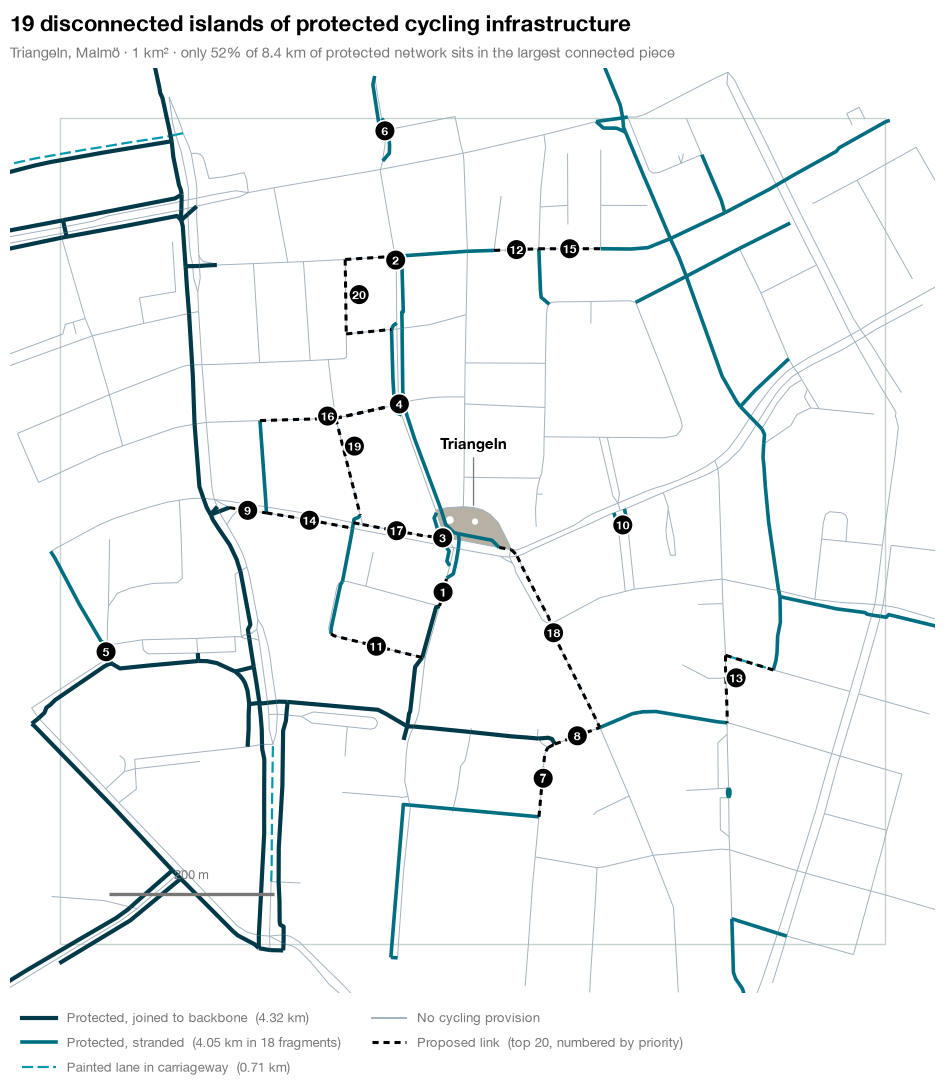

In [16]:
edges["comp"] = [comp_of_node.get(u) if cls == PROTECTED else None
                 for (u, v, k), cls in zip(edges.index, edges["infra"])]

layer_none = edges[edges["infra"] == MIXED]
layer_lane = edges[edges["infra"] == LANE]
layer_main = edges[(edges["infra"] == PROTECTED) & (edges["comp"] == 0)]
layer_frag = edges[(edges["infra"] == PROTECTED) & (edges["comp"] != 0) & edges["comp"].notna()]

fig, ax = plt.subplots(figsize=(11, 11))
aoi_gdf.boundary.plot(ax=ax, color=GRID, linewidth=1.0, zorder=1)

# Triangeln itself, under the network: a warm area among cool lines, so it reads
# as place rather than as another infrastructure class.
if TRIANGELN_M.geom_type in ("Polygon", "MultiPolygon"):
    gpd.GeoSeries([TRIANGELN_M], crs=CRS_METRIC).plot(
        ax=ax, color=C_PLACE, edgecolor="none", alpha=0.9, zorder=1.5)
else:
    ax.plot(TRIANGELN_M.x, TRIANGELN_M.y, marker="o", markersize=9,
            color=C_PLACE, zorder=1.5)

# Direct label with a short leader, so the shape is named rather than guessed.
_tb = TRIANGELN_M.bounds
_tx, _ty = (_tb[0] + _tb[2]) / 2, _tb[3]
ax.annotate(
    "Triangeln", xy=(_tx, _ty), xytext=(_tx, _ty + 66),
    ha="center", va="bottom", fontsize=10.5, fontweight="bold", color=INK,
    zorder=8,
    arrowprops=dict(arrowstyle="-", color=INK_2, linewidth=0.9, shrinkA=2, shrinkB=1),
)

# Line weight climbs with the teal ramp, so provision level is carried by
# colour AND weight; the painted lane is dashed, as it is on the ground.
# GeoPandas raises on plotting an empty frame, so each layer is guarded.
for layer, colour, width, dashes, z in [
    (layer_none, C_NONE,     0.7, "solid",     2),
    (layer_lane, C_LANE,     1.6, (0, (5, 2)), 3),
    (layer_frag, C_FRAGMENT, 2.6, "solid",     4),
    (layer_main, C_MAIN,     3.0, "solid",     5),
]:
    if len(layer):
        layer.plot(ax=ax, color=colour, linewidth=width, linestyle=dashes, zorder=z)

if len(gaps):
    top = gaps.head(TOP_N)
    top.plot(ax=ax, color=C_GAP, linewidth=2.2, linestyle=(0, (2, 1.6)), zorder=6)
    for row in top.itertuples():
        if row.geometry is None or row.geometry.is_empty:
            continue
        pt = row.geometry.centroid
        ax.annotate(
            str(row.rank), xy=(pt.x, pt.y),
            ha="center", va="center", fontsize=8.5, fontweight="bold",
            color=SURFACE, zorder=7,
            bbox=dict(boxstyle="circle,pad=0.28", facecolor=C_GAP,
                      edgecolor=SURFACE, linewidth=1.2),
        )

lane_km = summary.loc[LANE, "km"] if LANE in summary.index else 0.0
handles = [
    Line2D([], [], color=C_MAIN, lw=3.0,
           label=f"Protected, joined to backbone  ({largest_m/1000:.2f} km)"),
    Line2D([], [], color=C_FRAGMENT, lw=2.6,
           label=f"Protected, stranded  ({stranded_m/1000:.2f} km in {n_comp-1} fragments)"),
    Line2D([], [], color=C_LANE, lw=1.6, ls=(0, (5, 2)),
           label=f"Painted lane in carriageway  ({lane_km:.2f} km)"),
    Line2D([], [], color=C_NONE, lw=1.4,
           label="No cycling provision"),
    Line2D([], [], color=C_GAP, lw=2.2, ls=(0, (2, 1.6)),
           label=f"Proposed link  (top {min(TOP_N, len(gaps))}, numbered by priority)"),
]
# Below the axes, not inside: at 1 km2 there is no empty corner that does not
# cover network, and an occluded link is a lost finding.
legend = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.0, -0.005),
                   ncol=2, frameon=False, fontsize=9.5,
                   handlelength=2.6, columnspacing=2.4, labelspacing=0.7)
for text in legend.get_texts():
    text.set_color(INK_2)

ax.set_title(f"{n_comp} disconnected islands of protected cycling infrastructure",
             fontsize=16, fontweight="bold", color=INK, loc="left", pad=14)
ax.text(0.0, 1.008,
        f"Triangeln, Malm\u00f6 \u00b7 1 km\u00b2 \u00b7 only "
        f"{100*largest_m/total_protected_m:.0f}% of "
        f"{total_protected_m/1000:.1f} km of protected network sits in the largest "
        f"connected piece",
        transform=ax.transAxes, fontsize=10.5, color=INK_2, va="bottom")

# 200 m scale bar
x0, y0, x1, y1 = AOI_M.bounds
bx, by = x0 + 60, y0 + 60
ax.plot([bx, bx + 200], [by, by], color=INK_2, lw=2.4, solid_capstyle="butt", zorder=8)
ax.text(bx + 100, by + 18, "200 m", ha="center", fontsize=9, color=INK_2, zorder=8)

ax.set_xlim(x0 - 60, x1 + 60)
ax.set_ylim(y0 - 60, y1 + 60)
ax.set_aspect("equal")
ax.set_axis_off()

fig.tight_layout()
fig.savefig(OUT_DIR / "triangeln_cycling_fragmentation_map.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Priority ranking

A single series, so the bars need no legend — the title names the measure. Value labels sit
directly on the bars, and the gap length that produced each score is carried as a secondary
label, so the chart is readable without cross-referencing the table above.

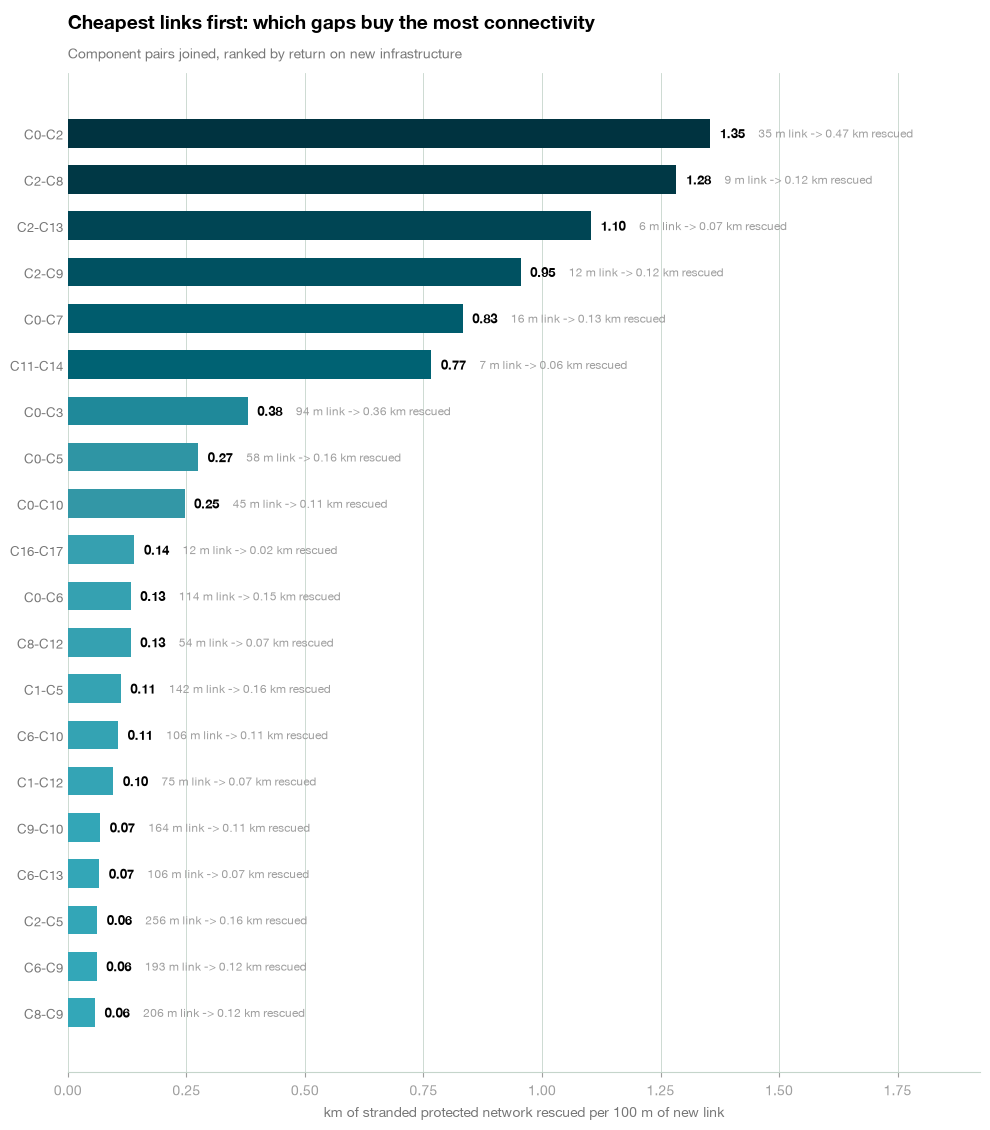

In [17]:
if len(gaps):
    top = gaps.head(TOP_N).iloc[::-1]  # highest score at the top of a barh
    norm = mpl.colors.Normalize(vmin=top["score"].min(), vmax=top["score"].max())
    ramp = mpl.colors.LinearSegmentedColormap.from_list("white_teal", SEQ_TEAL)
    colors = [ramp(0.15 + 0.85 * norm(v)) for v in top["score"]]

    fig, ax = plt.subplots(figsize=(10, 0.46 * len(top) + 2.2))
    ax.barh(top["label"], top["score"], height=0.62, color=colors, zorder=3)

    span = top["score"].max()
    for row in top.itertuples():
        ax.text(row.score + span * 0.015, row.label, f"{row.score:.2f}",
                va="center", fontsize=9.5, color=INK, fontweight="bold", zorder=4)
        ax.text(row.score + span * 0.075, row.label,
                f"{row.gap_m:.0f} m link -> {row.rescued_km:.2f} km rescued",
                va="center", fontsize=8.5, color=INK_MUTED, zorder=4)

    ax.set_xlim(0, span * 1.42)
    ax.set_xlabel("km of stranded protected network rescued per 100 m of new link",
                  fontsize=10)
    ax.set_title("Cheapest links first: which gaps buy the most connectivity",
                 fontsize=14, fontweight="bold", color=INK, loc="left", pad=32)
    ax.text(0.0, 1.012, "Component pairs joined, ranked by return on new infrastructure",
            transform=ax.transAxes, fontsize=10, color=INK_2, va="bottom")

    ax.xaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="y", length=0, labelsize=9.5, colors=INK_2)

    fig.tight_layout()
    fig.savefig(OUT_DIR / "triangeln_missing_link_priority.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Nothing to rank.")

## 9. Export

In [18]:
comp_geoms = []
for i, comp in enumerate(components):
    sub = P.subgraph(comp)
    keys = list(sub.edges(keys=True))
    geoms = [edge_geometry(P, u, v, k) for u, v, k in keys]
    comp_geoms.append({
        "component": i,
        "nodes": len(comp),
        "length_m": component_length_m(P, comp),
        "is_main": i == 0,
        "geometry": unary_union(geoms),
    })

comp_gdf = gpd.GeoDataFrame(comp_geoms, geometry="geometry", crs=CRS_METRIC)

_wanted = ["u", "v", "key", "infra", "comp", "length", "highway", "name", "geometry"]
_flat = edges.reset_index()
export_edges = _flat[[c for c in _wanted if c in _flat.columns]].copy()

# GPKG cannot hold list-valued fields, so collapse merged OSM tags to a string.
for col in ("highway", "name"):
    if col in export_edges.columns:
        export_edges[col] = export_edges[col].map(
            lambda v: ", ".join(sorted(tagset(v))) or None
        )

layers = {
    "edges_classified": export_edges,
    "protected_components": comp_gdf,
    "aoi": aoi_gdf,
    "triangeln": gpd.GeoDataFrame({"name": ["Triangeln"]},
                                  geometry=[TRIANGELN_M], crs=CRS_METRIC),
}
if len(gaps):
    layers["missing_links"] = gaps.copy()

gpkg = OUT_DIR / "triangeln_cycling_fragmentation.gpkg"
try:
    for name, gdf in layers.items():
        gdf.to_file(gpkg, layer=name, driver="GPKG")
    print(f"wrote {gpkg}  ({', '.join(layers)})")
except Exception as exc:
    print(f"GeoPackage write failed ({exc}); falling back to GeoJSON")
    for name, gdf in layers.items():
        gdf.to_file(OUT_DIR / f"triangeln_{name}.geojson", driver="GeoJSON")

comp_table.drop(columns=["length_m"]).to_csv(OUT_DIR / "triangeln_components.csv", index=False)
if len(gaps):
    gaps.drop(columns=["geometry"]).to_csv(OUT_DIR / "triangeln_missing_links_ranked.csv", index=False)
if len(build):
    build.to_csv(OUT_DIR / "triangeln_build_order.csv", index=False)

print("tables written to", OUT_DIR.resolve())

wrote ../OUT/triangeln_cycling_fragmentation.gpkg  (edges_classified, protected_components, aoi, triangeln, missing_links)
tables written to /Users/libnypacheco/Desktop/GIS-Urban-Analyses/malmo-network-analysis/OUT


## Caveats

- **Edge effects.** A 1 km² window truncates the network. A component that looks stranded
  here may continue outside the frame, and a gap may already be closed just beyond it.
  Re-run on a larger AOI before treating any single link as a real recommendation — the
  method is scale-independent, the numbers are not.
- **OSM completeness.** `cycleway:left/right` tagging is uneven. Malmö's coverage is good,
  but a missing tag reads as mixed traffic and will invent a gap. Spot-check the top-ranked
  links against aerial imagery.
- **Topological vs. legal continuity.** Two protected ways meeting at a node count as
  connected even if the actual movement requires dismounting or crossing against a signal.
  Adding a crossing/signal penalty would sharpen this.
- **`length` after projection.** OSMnx computes `length` geodesically on the WGS84 graph;
  it is retained through `project_graph`. Differences against SWEREF99 TM planar lengths
  are sub-metre at this scale.
- **Shared paths.** With `INCLUDE_SHARED_PATHS = True`, combined foot/cycle paths count as
  protected. This is the right call for motor-traffic severance but hides pedestrian
  conflict; re-run with `False` to see the dedicated-cycleway-only picture.

## Next steps

- Widen to all of central Malmö and rank links city-wide.
- Weight `rescued_km` by population or trip demand (SCB DeSO) instead of raw length, so the
  score reflects riders served rather than metres of asset.
- Add the Level of Traffic Stress classification, and measure gaps on the LTS ≤ 2 subgraph.
- Feed the gap edges back as labels for the DGL/GNN pipeline from the earlier flood work.